In [1]:
import pulp as pl
import networkx as nx

In [11]:
def get_m_degree(G):
    X = [0 for _ in range(0, len(G.nodes())+1)]
    Z = [0 for _ in range(0, len(G.nodes())+1)]
    max_j = 0
    for u in G.nodes(): X[G.degree(u)] += 1
    for j in range(len(G.nodes())-1, 0, -1): Z[j] = Z[j+1] + X[j]
    for j in range(1, len(G.nodes)):
        if Z[j-1] >= j:
            max_j = j
    return max_j

#### Choosing a random Graph

In [2]:
G = nx.fast_gnp_random_graph(10,0.5)

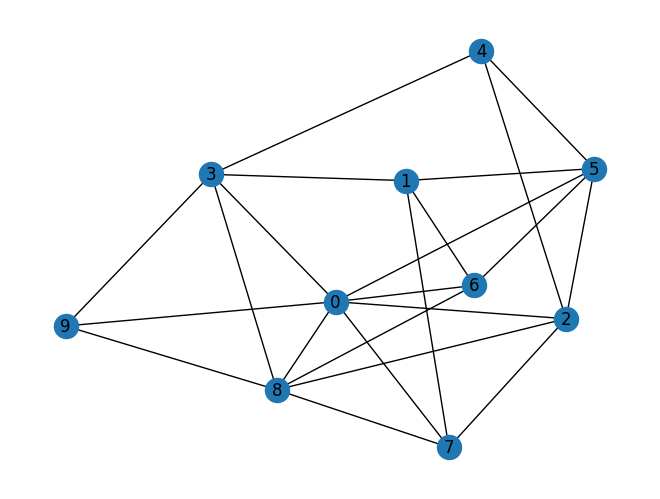

In [6]:
nx.draw(G, with_labels=True)

#### Model definition

In [16]:
b_chr_model = pl.LpProblem(name="b-chromatic-model")

#### Variables definition

In [17]:
n = len(G.nodes) #number of vertices
V = list(G.nodes)
c =  get_m_degree(G)#number of colours
C = range(c)

$x_{vc},z_{vc}\in \{0,1\} \hspace{1cm}\forall v\in V, \forall c\in C$

$d_c\in \{0,1\}\hspace{1cm}\forall c \in C$

In [18]:
x_vars = {(v,c):pl.LpVariable(
                             cat=pl.LpBinary,
                             name="x_{0}_{1}".format(v,c))
            for v in V for c in C}

z_vars = {(v,c):pl.LpVariable(
                             cat=pl.LpBinary,
                             name="z_{0}_{1}".format(v,c))
            for v in V for c in C}

d_vars = {c:pl.LpVariable(
                cat=pl.LpBinary,
                name="d_{0}".format(c))
             for c in C}

#### Constraints

$\sum_{c\in C}x_{vc}=1\hspace{1cm}\forall v\in V$

In [19]:
one_colour_constraint = {v:b_chr_model.addConstraint(
                            pl.LpConstraint(
                                e=pl.lpSum(x_vars[v,c] for c in C),
                                sense=pl.LpConstraintEQ,
                                rhs=1,
                                name="one_colour_{}".format(v))
                        ) for v in V}

$x_{vc}+x_{wc}\leq 1\hspace{1cm}\forall vw\in E, \forall c\in C$

In [21]:
diff_colour_per_edge_constraint = {(v,w,c):b_chr_model.addConstraint(
                                            pl.LpConstraint(
                                                e=x_vars[v,c]+x_vars[w,c],
                                                sense=pl.LpConstraintLE,
                                                rhs=1,
                                                name="diff_colour_{0}_{1}_{2}".format(v,w,c)
                                            )) 
                                   for v, w in G.edges for c in C}

$z_{vc}\leq \sum_{w\in N(v)}x_{wd}\hspace{1cm} \forall v\in V,\forall c,d\in C, c\neq d$

In [22]:
b_chromatic_vertex_constraint = {(v,c,d):b_chr_model.addConstraint(
                                            pl.LpConstraint(
                                                e=z_vars[v,c],
                                                sense=pl.LpConstraintLE,
                                                rhs=pl.lpSum(x_vars[w,d] for w in V),
                                                name="b_chr_vertex_{0}_{1}_{2}".format(v,c,d)
                                            )
                                        )
                                 for v in V for c in C for d in C if c!=d}

$d_c\leq \sum_{v\in V}z_{vc}\hspace{1cm} c\in C$

In [23]:
b_chromatic_vertices_constraint = {c:b_chr_model.addConstraint(
                                        pl.LpConstraint(
                                            e=d_vars[c],
                                            sense=pl.LpConstraintLE,
                                            rhs=pl.lpSum(z_vars[v,c] for v in V),
                                            name="b_chro_colour_{0}".format(c)
                                        )
                                    )
                                  for c in C}

#### Objective function

In [24]:
b_chromatic_number = pl.lpSum(d_vars[c] for c in C)

In [25]:
b_chr_model.sense = pl.LpMaximize
b_chr_model.setObjective(b_chromatic_number)

In [28]:
b_chr_model.solve(solver=pl.get_solver("GUROBI_CMD"))

Set parameter Username
Set parameter LogFile to value "gurobi.log"
Academic license - for non-commercial use only - expires 2024-02-23
Using license file /home/fabricio/gurobi.lic

Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (linux64)
Copyright (c) 2023, Gurobi Optimization, LLC

Read LP format model from file /tmp/a00576914a244f88ace1afcff05a42b5-pulp.lp
Reading time = 0.00 seconds
OBJ: 330 rows, 105 columns, 485 nonzeros

CPU model: Intel(R) Core(TM) i7-10700 CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 330 rows, 105 columns and 485 nonzeros
Model fingerprint: 0x7bba635d
Variable types: 0 continuous, 105 integer (105 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -0.0000000
Presolve removed 275 rows and 55 columns
Presolve 

1